In [ ]:
install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("readr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(sqldf)
library(dplyr)
library(ggplot2)
library(readr)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
library(base64enc)
customers  <- read_csv("customers.csv")
orders     <- read_csv("orders.csv")
deliveries <- read_csv("deliveries.csv")
drivers    <- read_csv("drivers.csv")
vehicles   <- read_csv("vehicles.csv")
hubs       <- read_csv("hubs.csv")
incidents  <- read_csv("incidents.csv")
complaints <- read_csv("complaints.csv")
app_events <- read_csv("app_events.csv")

cat("All files loaded successfully\n")
cat("Orders:", nrow(orders), "\n")
cat("Deliveries:", nrow(deliveries), "\n")
cat("Complaints:", nrow(complaints), "\n")

Rows: 650 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6)

All files loaded successfully
Orders: 1250 
Deliveries: 950 
Complaints: 320 


In [ ]:
clean_zone <- function(z) toupper(trimws(z))

customers$home_zone   <- clean_zone(customers$home_zone)
orders$pickup_zone    <- clean_zone(orders$pickup_zone)
orders$dropoff_zone   <- clean_zone(orders$dropoff_zone)
drivers$base_zone     <- clean_zone(drivers$base_zone)
vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)
hubs$zone             <- clean_zone(hubs$zone)

cat("Zone names standardised\n")

Zone names standardised


In [ ]:
q1 <- sqldf("
  SELECT
    h.hub_name,
    h.zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(*), 2) AS failure_rate_pct
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_name, h.zone
  ORDER BY failure_rate_pct DESC
")

print(q1)

        hub_name      zone total_deliveries failed delayed failure_rate_pct
1  Midtown Relay   CENTRAL              128     26      22            20.31
2   Central Core   CENTRAL              115     23      25            20.00
3    Airport Hub   AIRPORT              104     15      27            14.42
4      West Gate      WEST              127     16      28            12.60
5 North Exchange     NORTH              136     17      26            12.50
6  Riverside Hub RIVERSIDE              115     14      25            12.17
7     South Link     SOUTH              106     10      26             9.43
8      East Dock      EAST              119     11      23             9.24


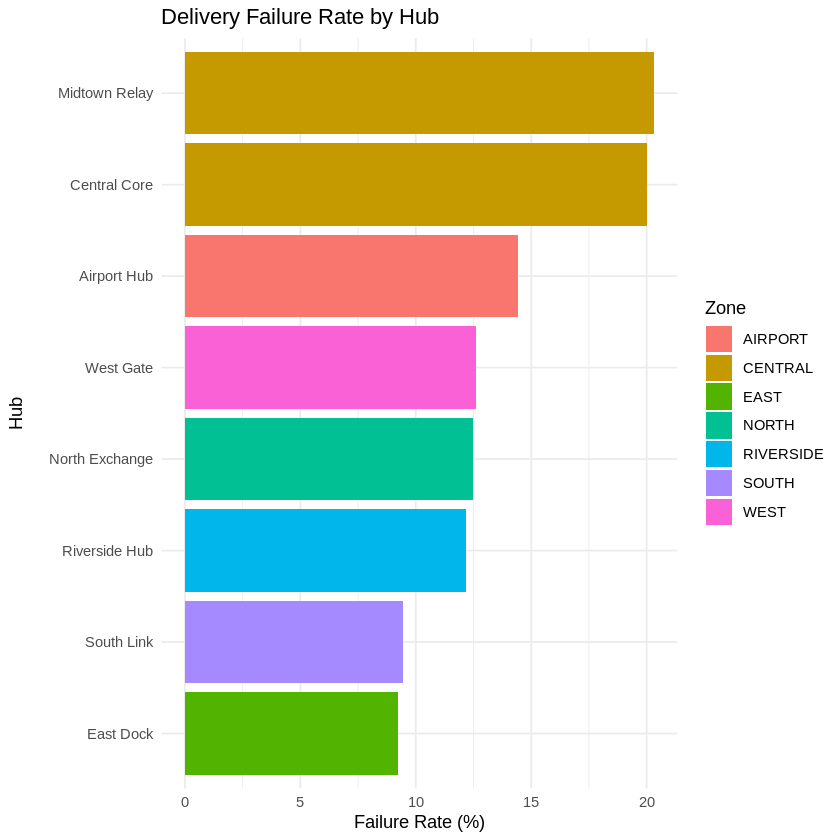

In [ ]:
ggplot(q1, aes(x = reorder(hub_name, failure_rate_pct), y = failure_rate_pct, fill = zone)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Delivery Failure Rate by Hub",
    x = "Hub",
    y = "Failure Rate (%)",
    fill = "Zone"
  ) +
  theme_minimal()

In [ ]:
q2 <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(d.manual_route_override_count) AS total_overrides,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides_per_delivery
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY avg_overrides_per_delivery DESC
")

print(q2)

  pickup_zone total_deliveries total_overrides avg_overrides_per_delivery
1     AIRPORT              113             204                       1.81
2     CENTRAL              110             178                       1.62
3        WEST              114              92                       0.81
4        EAST              156             123                       0.79
5   RIVERSIDE              119              87                       0.73
6         CTR               64              47                       0.73
7       NORTH              135              94                       0.70
8       SOUTH              139              96                       0.69


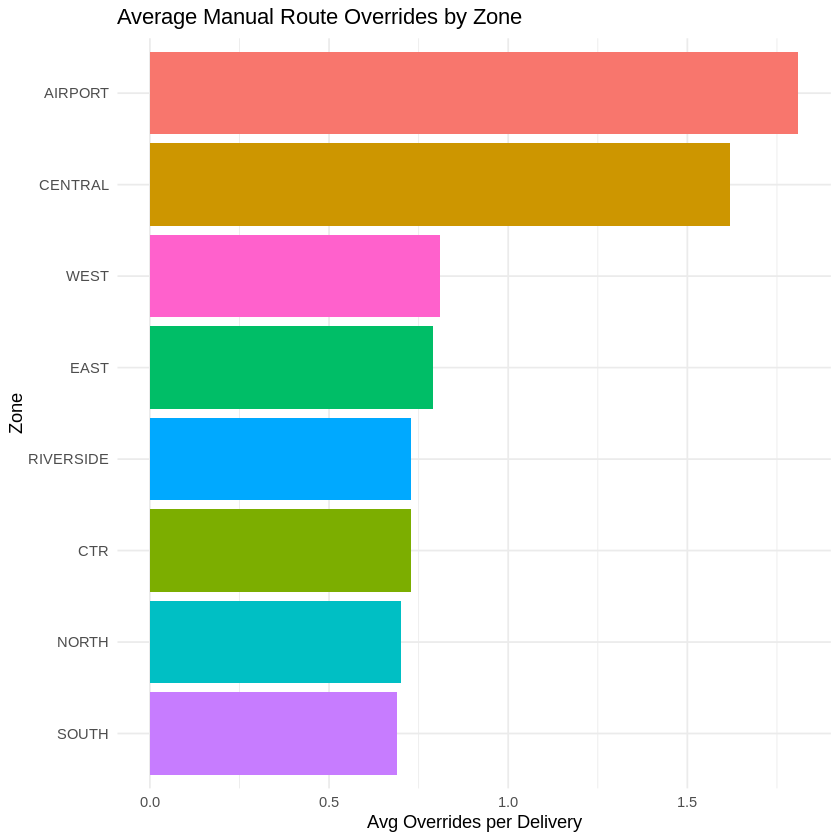

In [ ]:
ggplot(q2, aes(x = reorder(pickup_zone, avg_overrides_per_delivery),
               y = avg_overrides_per_delivery, fill = pickup_zone)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Average Manual Route Overrides by Zone",
    x = "Zone",
    y = "Avg Overrides per Delivery"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

In [ ]:
q3 <- sqldf("
  SELECT
    c.complaint_type,
    c.severity,
    c.channel,
    COUNT(c.complaint_id) AS total_complaints,
    ROUND(AVG(c.resolution_days), 2) AS avg_resolution_days,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation
  FROM complaints c
  GROUP BY c.complaint_type, c.severity, c.channel
  ORDER BY total_complaints DESC
")

print(q3)

      complaint_type severity channel total_complaints avg_resolution_days
1              Delay   Medium     App               21                7.00
2              Delay   Medium   Phone               16                5.25
3       MissedPickup   Medium   Phone               15                5.20
4              Delay   Medium Chatbot               13                5.85
5       MissedPickup   Medium     App               11                6.91
6    DriverBehaviour   Medium   Phone               10                5.20
7           AppIssue   Medium     App                8                7.63
8           AppIssue   Medium   Phone                8                8.38
9              Delay      Low Chatbot                8                4.13
10             Delay      Low   Email                8                7.63
11   DriverBehaviour   Medium     App                8                5.13
12             Delay     High   Email                7               12.71
13             Delay     

In [ ]:
q4 <- sqldf("
  SELECT
    dr.driver_id,
    dr.base_zone,
    dr.employment_type,
    dr.driver_rating,
    dr.training_score,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY dr.driver_id, dr.base_zone, dr.employment_type, dr.driver_rating, dr.training_score
  ORDER BY failed_deliveries DESC
  LIMIT 20
")

print(q4)

   driver_id base_zone employment_type driver_rating training_score
1       D024 RIVERSIDE        PartTime          3.35           71.4
2       D104      WEST        FullTime          3.45           87.7
3       D133     SOUTH        Contract          3.99           88.2
4       D004   AIRPORT        PartTime          4.75           88.9
5       D010      WEST        FullTime          3.95           70.0
6       D055   CENTRAL        FullTime          5.00           90.5
7       D083     NORTH        FullTime          4.16           80.8
8       D092      EAST        FullTime          4.24           88.2
9       D108     SOUTH        FullTime          4.33           70.6
10      D131     SOUTH        FullTime          4.26           86.7
11      D005     NORTH        FullTime          4.14           69.7
12      D017      EAST        PartTime          4.34             NA
13      D018      WEST        PartTime          4.57           73.8
14      D023      EAST        FullTime          

In [ ]:
q5 <- sqldf("
  SELECT
    v.vehicle_id,
    v.vehicle_type,
    v.assigned_zone,
    v.maintenance_status,
    v.battery_health_pct,
    COUNT(i.incident_id) AS total_incidents,
    GROUP_CONCAT(DISTINCT i.incident_type) AS incident_types
  FROM vehicles v
  LEFT JOIN deliveries d ON v.vehicle_id = d.vehicle_id
  LEFT JOIN incidents i ON d.delivery_id = i.delivery_id
  GROUP BY v.vehicle_id, v.vehicle_type, v.assigned_zone, v.maintenance_status, v.battery_health_pct
  HAVING total_incidents > 0
  ORDER BY total_incidents DESC
  LIMIT 15
")

print(q5)

   vehicle_id vehicle_type assigned_zone maintenance_status battery_health_pct
1        V047           EV           CTR          Scheduled               93.7
2        V108       Diesel       AIRPORT           InRepair               54.6
3        V030     CargoVan         NORTH             Active               78.0
4        V046           EV         NORTH             Active               95.8
5        V097           EV           CTR             Active               92.1
6        V005     CargoVan          WEST             Active               58.6
7        V009     CargoVan         SOUTH             Active               68.8
8        V035     CargoVan          EAST             Active               83.6
9        V042           EV          EAST           InRepair               80.5
10       V076       Diesel       CENTRAL           InRepair               65.8
11       V088       Diesel         NORTH           InRepair               80.3
12       V001           EV         NORTH            

In [ ]:
q6 <- sqldf("
  SELECT
    o.service_type,
    o.priority_level,
    COUNT(o.order_id) AS total_orders,
    ROUND(AVG(o.order_value), 2) AS avg_order_value,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost,
    ROUND(AVG(o.order_value) - AVG(d.fuel_or_charge_cost), 2) AS avg_margin
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type, o.priority_level
  ORDER BY avg_margin DESC
")

print(q6)

   service_type priority_level total_orders avg_order_value avg_cost avg_margin
1     Passenger           High           61          104.59    12.73      91.86
2      Business       Critical           10          102.06    11.98      90.08
3     Passenger       Critical           19          100.59    10.97      89.62
4      Business         Medium           55          100.48    13.41      87.06
5        Parcel           High           62           99.46    12.89      86.57
6     Passenger            Low           77           95.60    12.15      83.45
7      Business            Low           26           95.60    12.71      82.88
8       Medical         Medium           40           95.66    13.62      82.04
9     Passenger         Medium          105           93.44    12.65      80.79
10     Business           High           35           92.77    13.37      79.40
11       Retail         Medium           97           91.37    13.40      77.96
12      Medical           High          

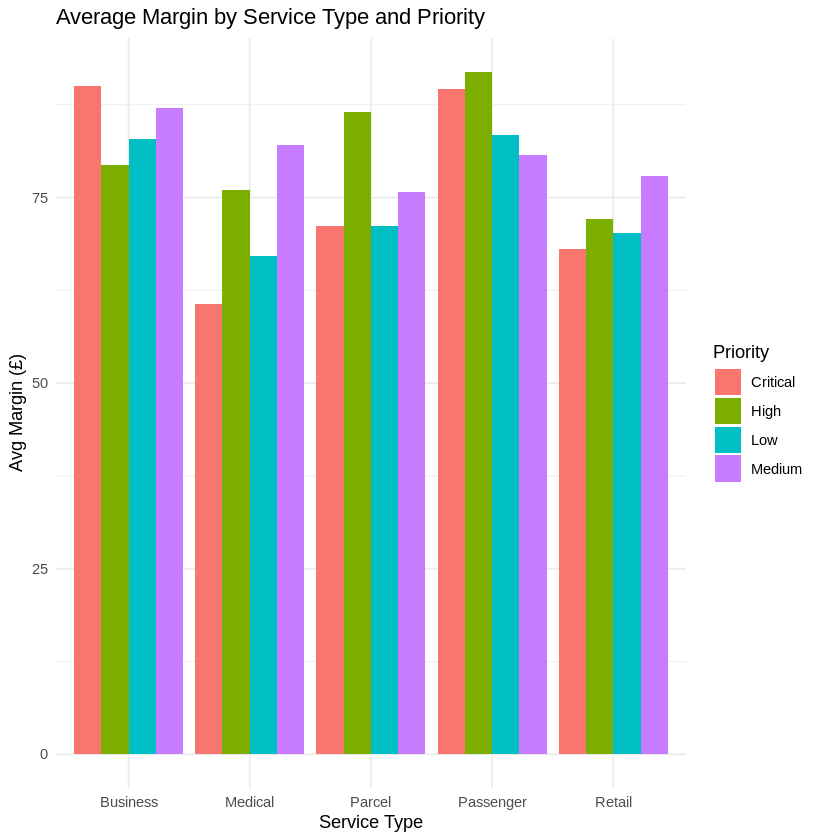

In [ ]:
ggplot(q6, aes(x = service_type, y = avg_margin, fill = priority_level)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Average Margin by Service Type and Priority",
    x = "Service Type",
    y = "Avg Margin (£)",
    fill = "Priority"
  ) +
  theme_minimal()

In [ ]:
q7 <- sqldf("
  SELECT
    c.customer_id,
    cu.home_zone,
    cu.customer_type,
    cu.loyalty_score,
    COUNT(c.complaint_id) AS complaint_count,
    SUM(c.compensation_amount) AS total_compensation,
    GROUP_CONCAT(DISTINCT c.complaint_type) AS complaint_types
  FROM complaints c
  JOIN customers cu ON c.customer_id = cu.customer_id
  GROUP BY c.customer_id, cu.home_zone, cu.customer_type, cu.loyalty_score
  HAVING complaint_count > 1
  ORDER BY complaint_count DESC
  LIMIT 15
")

print(q7)

   customer_id home_zone customer_type loyalty_score complaint_count
1        C0368     NORTH      Consumer          49.5               4
2        C0110      EAST      Consumer            NA               3
3        C0142     SOUTH      Consumer          47.0               3
4        C0172     NORTH      Consumer          75.4               3
5        C0191     NORTH      Consumer          58.9               3
6        C0242      EAST      Consumer          83.8               3
7        C0282 RIVERSIDE      Consumer          71.4               3
8        C0372      WEST      Consumer          26.2               3
9        C0421   CENTRAL      Consumer          59.0               3
10       C0545     SOUTH      Consumer          66.9               3
11       C0573   AIRPORT           SME          57.3               3
12       C0626     SOUTH      Consumer          61.6               3
13       C0001     NORTH           SME          44.9               2
14       C0004   CENTRAL      Cons